In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Exercise 1

### Fetch Data

In [2]:
tickers = ["QQQ", "TQQQ"]  # underlying ETF, leveraged ETF (3x)
start_date = "2023-01-01"
end_date = "2024-12-31"

print("Downloading data from Yahoo Finance...")
data = yf.download(tickers, start=start_date, end=end_date)["Close"]
data.columns = ["S_t", "L_t"]
data = data.dropna()

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed

Data shape: (501, 2)
Date range: 2023-01-03 00:00:00 to 2024-12-30 00:00:00


### Inputs

In [3]:
k = 40
r = 0.05
f = 0.009

### Calculate Period Returns and Variance

In [4]:
def calc_period_returns_and_var(data, k):
    """
    Calculate period returns and variance

    Args:
        data: Input data
        k: Number of days in a period

    Returns:
        tuple: Tuple of period returns and variance
    """
    rts = np.log(data / data.shift(1)).dropna()
    groups = np.arange(len(rts)) // k
    per_rts = rts.groupby(groups).sum()
    per_var = rts.groupby(groups).var()
    return per_rts, per_var

In [5]:
# use k=5 for parts a and b
per_rts, per_var = calc_period_returns_and_var(data, k=k)

### Part (a): OLS

In [6]:
def calc_r_squared(y, y_pred):
    """
    Calculate R-squared for a given set of actual and predicted values

    Args:
        y: Actual values
        y_pred: Predicted values

    Returns:
        float: R-squared value
    """
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res / ss_tot

def ols_estimation(rts_und, rts_lev, var_und):
    """
    Perform OLS estimation for part (a) and (c)

    Model: ln(L_t/L_0) = β̂ * ln(S_t/S_0) + θ̂ * V_t + α̂ + ε_t

    Args:
        rts_und: Underlying returns
        rts_lev: Leveraged returns
        var_und: Underlying variance

    Returns:
        dict: OLS estimation results
    """
    X = np.column_stack([np.ones(len(rts_und)), rts_und, var_und])
    y = rts_lev

    # OLS using normal equations
    beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]

    # Calculate statistics
    y_pred = X @ beta_ols
    r_squared = calc_r_squared(y, y_pred)

    # Standard errors
    mse = np.sum((y - y_pred)**2) / (len(y) - 3)
    var_beta = mse * np.linalg.inv(X.T @ X)
    std_errors = np.sqrt(np.diag(var_beta))

    return {
        'alpha': beta_ols[0],
        'beta': beta_ols[1],
        'theta': beta_ols[2],
        'theta_theo': calc_theta_from_beta(beta_ols[1]),
        'r_squared': r_squared,
        'std_errors': std_errors
    }

def calc_theta_from_beta(beta):
    """
    Calculate theta from beta

    Args:
        beta: Beta value

    Returns:
        float: Theta value
    """
    return beta * (1 - beta) / 2

In [7]:
pd.Series(ols_estimation(per_rts['S_t'], per_rts['L_t'], per_var['S_t']))

alpha                                                 -0.021967
beta                                                   2.980413
theta                                                -83.682822
theta_theo                                            -2.951224
r_squared                                              0.998993
std_errors    [0.005825383964069601, 0.030101876492870012, 4...
dtype: object

There are several issues in interpreting and using the coefficients in practice.
- There is strong dependency between the return of the underlying $log(S_t/S_0)$ and the variance of the underlying $V_t$. This causes collinerearity issues.
- The OLS regression estimates $\hat{\theta}$, but there is also a theoretical representation of this parameter in terms of the leverage ratio: $\beta(1-\beta)/2$. This leads to another method of estimating $\hat{\beta}$. There is no guarantee that the two estimates will be equal. In fact, there is evidence that the two deviate significantly.

### Part (b): Non-linear least squares

In [8]:
def theoretical_return(beta, x, v, delta_t, r, f):
    """
    Calculate theoretical return for nonlinear estimation

    f_i(β) = β*x_i - β(β-1)/2 * v_i + (1-β)*r*Δt - f*Δt

    Args:
        beta: Beta parameter
        x: Underlying returns
        v: Underlying variance
        delta_t: Time interval
        r: Risk-free rate
        f: Management fee

    Returns:
        float: Theoretical return
    """
    return beta * x - beta * (beta - 1) / 2 * v + ((1 - beta) * r - f) * delta_t

def nls_estimation(rts_und, rts_lev, var_und, k, r, f, beta_init=3.0, beta_bounds=(0.5, 5.0)):
    """
    Perform nonlinear least squares estimation for parts (b) and (c)

    Args:
        rts_und: Underlying returns
        rts_lev: Leveraged returns
        var_und: Underlying variance
        k: Number of periods
        r: Risk-free rate
        f: Management fee
        beta_init: Initial guess at beta value
        beta_bounds: Beta bounds

    Returns:
        dict: Nonlinear least squares estimation results
    """
    delta_t = k / 252

    def objective(beta):
        rts_theoretical = theoretical_return(beta, rts_und, var_und, delta_t, r, f)
        residuals = rts_lev - rts_theoretical
        return np.sum(residuals**2)

    # Optimize
    result = minimize(objective, x0=beta_init, bounds=[beta_bounds], method='L-BFGS-B')
    beta_nls = result.x[0]

    # Calculate R-squared
    f_fitted = theoretical_return(beta_nls, rts_und, var_und, delta_t, r, f)
    r_squared = calc_r_squared(rts_lev, f_fitted)

    return {
        'beta': beta_nls,
        'theta': calc_theta_from_beta(beta_nls),
        'objective': result.fun,
        'r_squared': r_squared,
        'success': result.success
    }

In [9]:
pd.Series(nls_estimation(per_rts['S_t'], per_rts['L_t'], per_var['S_t'], k=k, r=r, f=f))

beta         2.850958
theta       -2.638502
objective    0.002468
r_squared    0.993245
success          True
dtype: object

The beta coefficient estimation is extremely close to target for both OLS and NLS. However, the realized theta (volatility coefficient) in OLS is far off the theoretical value. The optimization approach solves only for beta and computes theta based on the beta value. This ensures the relationship is consistent. For OLS no such constraint for the relationship exists.

### Part (c): Holding Period Comparison

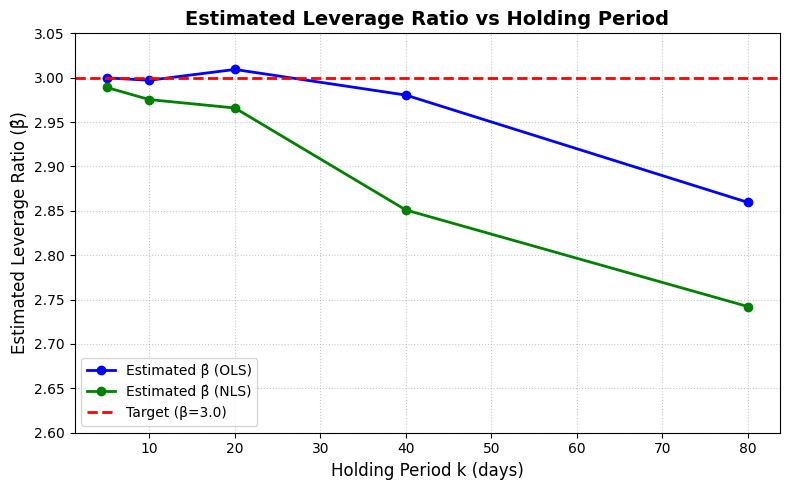

In [10]:
# Data from previous analysis
holding_periods = np.array([5, 10, 20, 40, 80])
estimated_beta_ols = []
estimated_beta_nls = []
target_beta = 3.0

for per in holding_periods:
    per_rts_tmp, per_var_tmp = calc_period_returns_and_var(data, k=per)
    res_ols = pd.Series(ols_estimation(per_rts_tmp['S_t'], per_rts_tmp['L_t'], per_var_tmp['S_t']))
    res_nls = pd.Series(nls_estimation(per_rts_tmp['S_t'], per_rts_tmp['L_t'], per_var_tmp['S_t'], k=per, r=r, f=f))
    estimated_beta_ols.append(res_ols['beta'])
    estimated_beta_nls.append(res_nls['beta'])

plt.figure(figsize=(8, 5))
plt.plot(holding_periods, estimated_beta_ols, marker='o', label='Estimated β̂ (OLS)', color='blue', linewidth=2)
plt.plot(holding_periods, estimated_beta_nls, marker='o', label='Estimated β̂ (NLS)', color='green', linewidth=2)
plt.axhline(y=target_beta, color='red', linestyle='--', linewidth=2, label='Target (β=3.0)')

plt.title("Estimated Leverage Ratio vs Holding Period", fontsize=14, fontweight='bold')
plt.xlabel("Holding Period k (days)", fontsize=12)
plt.ylabel("Estimated Leverage Ratio (β̂)", fontsize=12)
plt.ylim(2.6, 3.05)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()


The estimation of the leverage ratio deviates further from the target as the holding period increases. The main driver of this behavior is the volatility decay effect. For longer periods, the cumulative impact of volatility decay $-{\beta}({\beta}-1){\sigma}^2t$ is larger due to variance increasing with time. Other factors that impact the estimation include:
- Fewer data points for longer periods, leading to higher standard errors
- Cumulative costs - the expense ratio accumulate over longer periods

The pattern of leverage estimates across holding periods reveals these systematic effects and suggests that the leverage ratio is better understood as a daily target and not long-term guarantee.

## Exercise 2

### Title: VIX Term Structure and Multiscale Volatility: Explaining Multi-Day Levereage Drag in S&P 500 LEFTs

### Data

- **Prices (daily, adjusted close; 2010-2025 or max overlap):** SPY, SSO, UPRO, SDS, SPXU. Source: Yahoo! Finance
- **Implied vol term structure:** VIX (^VIX, 30-day), VIX3M (^VIX3M, 3-month)
- **Parameters:** expense ratios (fact sheets), risk free rate (FRED)

### Goal and tentative plan
**Motivation:** Multi-day returns of 2x/3x LETFs deviate from the naive $ k $ x benchmark because compounding creates variance drag. The VIX curve (VIX vs VIX 3M) is an observable proxy for whether volatility pressure is hear-term (VIX is high or slope is negative) or further out (contango). We test how scale-specific volatility and SPY <-> LEFT synchronization relate to LEFT drag across horizons.

**Objective:** Quantify the link between short, medium, and long-horizon volatility and the VIX term structure, and relawte it to multi-day departure of LETFs from $ k $ x SPY.

### Research Questions
1. How does varaince scale with horizon for SPY versus 2x3x LEFTs?
2. When the VIX curve flattens or inverts, odes short-horizon energy dominate?
3. Under which VIX level/slope states are multi-day drags $y_{t,k}-\beta_{target}x_{t,k}$ largest?
4. Do multi-horizon volatility summaries explain drag better than a single volatility measure?

#### Extension
Given today's VIX level, term structure slope, and short horizon volatility, what is the expected LEFT drag over the next $ h $ days, $ h \in \{1,5,10,22,66\} $?